# 9. Compare JEPA Phase A: frozen vs unfrozen

Side-by-side analysis of two full-data LPS Phase A runs (same recipe except freeze):

| Run | ID | Encoder | Freeze |
|-----|-----|---------|--------|
| **unfz** | `20260804_1120` | scmaskgit early-exit 3L | `false` |
| **fz** | `20260805_1128` | scmaskgit early-exit 3L | `true` |

Shared: cosine + VICReg (`var=1`, `cov=0.04`), global batch 256, LR 1e-4, pred times 1/2/3.

**What to look for**
- Pred loss / latent cosine (learning)
- Beats identity + identity baseline (is the task non-trivial?)
- Collapse mean cosine (high ≈ cells look the same — bad for biology)
- Per-time losses t1/t2/t3

Optional TensorBoard:
```bash
bash docs/examples/run_tensorboard_jepa.sh   # port 6007
```

In [2]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import yaml

LOG_ROOT = Path("/mnt/sod2-project/csb4/stuke1/perturbgen/logs")
OUT_DIR = Path("/home/stuke1/perturbgen/Perturbgen/docs/examples/jepa_compare_kept_runs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Kept Phase A runs (skip missing dirs in the load cell).
RUNS = {
    "unfz_1120": {
        "label": "unfz scmaskgit 3L",
        "dir": LOG_ROOT / "20260804_1120_cellgen",
        "color": "C0",
    },
    "fz_1128": {
        "label": "fz scmaskgit 3L",
        "dir": LOG_ROOT / "20260805_1128_cellgen",
        "color": "C1",
    },
    "cell_1622": {
        "label": "cell 3L + tok warmstart",
        "dir": LOG_ROOT / "20260805_1622_cellgen",
        "color": "C2",
    },
}

METRIC_COLS = [
    "train/jepa_pred_loss_epoch",
    "val/jepa_pred_loss",
    "train/jepa_loss_epoch",
    "val/jepa_loss",
    "train/latent_cosine",
    "val/latent_cosine",
    "val/beats_identity",
    "val/collapse_mean_cosine",
    "val/collapse_std_mean",
    "train/collapse_mean_cosine",
    "val/baseline_identity_cosine_loss",
    "val/baseline_jepa_cosine_loss",
    "val/baseline_identity_mse",
    "val/baseline_jepa_mse",
    "val/jepa_loss_t1",
    "val/jepa_loss_t2",
    "val/jepa_loss_t3",
    "train/vicreg_var",
    "train/vicreg_cov",
    "val/vicreg_var",
    "val/vicreg_cov",
]

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.3})
print("OUT_DIR", OUT_DIR)

OUT_DIR /home/stuke1/perturbgen/Perturbgen/docs/examples/jepa_compare_1120_vs_1128


## 1. Load metrics + hparams

In [3]:
def find_metrics_csv(run_dir: Path) -> Path:
    cands = sorted(run_dir.glob("version_*/metrics.csv"))
    if not cands:
        raise FileNotFoundError(f"No metrics.csv under {run_dir}")
    # prefer version_0 (CSVLogger) when present
    for c in cands:
        if c.parent.name == "version_0":
            return c
    return cands[0]


def load_hparams(run_dir: Path) -> dict:
    for p in sorted(run_dir.glob("version_*/hparams.yaml")):
        with open(p) as f:
            return yaml.safe_load(f) or {}
    return {}


def load_epoch_metrics(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    cols = [c for c in METRIC_COLS if c in df.columns]
    return df.groupby("epoch", as_index=True)[cols].last().sort_index()


tables = {}
hparams = {}
for name, meta in RUNS.items():
    csv_path = find_metrics_csv(meta["dir"])
    tables[name] = load_epoch_metrics(csv_path)
    hparams[name] = load_hparams(meta["dir"])
    print(f"{name}: {csv_path}  epochs={tables[name].index.min()}-{tables[name].index.max()}  n={len(tables[name])}")

unfz_1120: /mnt/sod2-project/csb4/stuke1/perturbgen/logs/20260804_1120_cellgen/version_0/metrics.csv  epochs=0-27  n=28
fz_1128: /mnt/sod2-project/csb4/stuke1/perturbgen/logs/20260805_1128_cellgen/version_0/metrics.csv  epochs=0-29  n=30


In [4]:
keys = [
    "freeze_jepa_encoder",
    "jepa_encoder",
    "jepa_encoder_layers",
    "loss_type",
    "vicreg_var_coeff",
    "vicreg_cov_coeff",
    "normalize_latents",
    "lr",
    "ema_decay",
    "d_model",
]
hp_rows = []
for name in RUNS:
    row = {"run": name}
    hp = hparams[name]
    for k in keys:
        row[k] = hp.get(k)
    hp_rows.append(row)
hp_df = pd.DataFrame(hp_rows)
hp_df

,run,freeze_jepa_encoder,jepa_encoder,jepa_encoder_layers,loss_type,vicreg_var_coeff,vicreg_cov_coeff,normalize_latents,lr,ema_decay,d_model
0,unfz_1120,False,scmaskgit,3,cosine,1.0,0.04,True,0.0001,0.996,768
1,fz_1128,True,scmaskgit,3,cosine,1.0,0.04,True,0.0001,0.996,768


## 2. Numeric summary

Best epoch = minimum `val/jepa_pred_loss` (cosine loss = 1 − cos).

In [5]:
def summarize(name: str, by: pd.DataFrame) -> dict:
    key = "val/jepa_pred_loss" if "val/jepa_pred_loss" in by else "val/jepa_loss"
    best_ep = int(by[key].idxmin())
    first_ep = int(by.index.min())
    last_ep = int(by.index.max())

    def g(ep, col):
        return float(by.loc[ep, col]) if col in by.columns else None

    return {
        "run": name,
        "label": RUNS[name]["label"],
        "epochs": f"{first_ep}-{last_ep}",
        "best_epoch": best_ep,
        "best_val_pred_loss": g(best_ep, "val/jepa_pred_loss"),
        "best_val_latent_cosine": g(best_ep, "val/latent_cosine"),
        "best_beats_identity": g(best_ep, "val/beats_identity"),
        "best_collapse_mean_cos": g(best_ep, "val/collapse_mean_cosine"),
        "best_identity_cos_loss": g(best_ep, "val/baseline_identity_cosine_loss"),
        "best_jepa_cos_loss": g(best_ep, "val/baseline_jepa_cosine_loss"),
        "best_t1": g(best_ep, "val/jepa_loss_t1"),
        "best_t2": g(best_ep, "val/jepa_loss_t2"),
        "best_t3": g(best_ep, "val/jepa_loss_t3"),
        "ep0_val_pred_loss": g(first_ep, "val/jepa_pred_loss"),
        "ep0_latent_cosine": g(first_ep, "val/latent_cosine"),
        "ep0_collapse_mean_cos": g(first_ep, "val/collapse_mean_cosine"),
        "ep0_identity_cos_loss": g(first_ep, "val/baseline_identity_cosine_loss"),
        "final_val_pred_loss": g(last_ep, "val/jepa_pred_loss"),
        "final_latent_cosine": g(last_ep, "val/latent_cosine"),
        "final_collapse_mean_cos": g(last_ep, "val/collapse_mean_cosine"),
    }


summary = pd.DataFrame([summarize(n, t) for n, t in tables.items()])
summary_path = OUT_DIR / "summary_from_notebook.csv"
summary.to_csv(summary_path, index=False)
print("Wrote", summary_path)
summary.T  # transpose for readable display

Wrote /home/stuke1/perturbgen/Perturbgen/docs/examples/jepa_compare_1120_vs_1128/summary_from_notebook.csv


,0,1
run,unfz_1120,fz_1128
label,unfz (encoder trainable),fz (encoder frozen)
epochs,0-27,0-29
best_epoch,17,28
best_val_pred_loss,0.065004,0.007008
best_val_latent_cosine,0.934996,0.992992
best_beats_identity,0.930944,1.0
best_collapse_mean_cos,0.856267,0.986445
best_identity_cos_loss,0.08302,0.014154
best_jepa_cos_loss,0.077588,0.008489


In [6]:
# Delta: fz minus unfz at each run's own best epoch (positive = fz higher)
u = summary.set_index("run").loc["unfz_1120"]
f = summary.set_index("run").loc["fz_1128"]
cmp_cols = [
    "best_val_pred_loss",
    "best_val_latent_cosine",
    "best_beats_identity",
    "best_collapse_mean_cos",
    "best_identity_cos_loss",
    "best_jepa_cos_loss",
]
delta = pd.DataFrame(
    {
        "unfz_best": [u[c] for c in cmp_cols],
        "fz_best": [f[c] for c in cmp_cols],
        "fz_minus_unfz": [f[c] - u[c] for c in cmp_cols],
    },
    index=cmp_cols,
)
delta

,unfz_best,fz_best,fz_minus_unfz
best_val_pred_loss,0.065004,0.007008,-0.057996
best_val_latent_cosine,0.934996,0.992992,0.057996
best_beats_identity,0.930944,1.000000,0.069056
best_collapse_mean_cos,0.856267,0.986445,0.130178
best_identity_cos_loss,0.083020,0.014154,-0.068866
best_jepa_cos_loss,0.077588,0.008489,-0.069099


## 3. Loss & cosine curves

Wrote /home/stuke1/perturbgen/Perturbgen/docs/examples/jepa_compare_1120_vs_1128/nb_loss_cosine.png


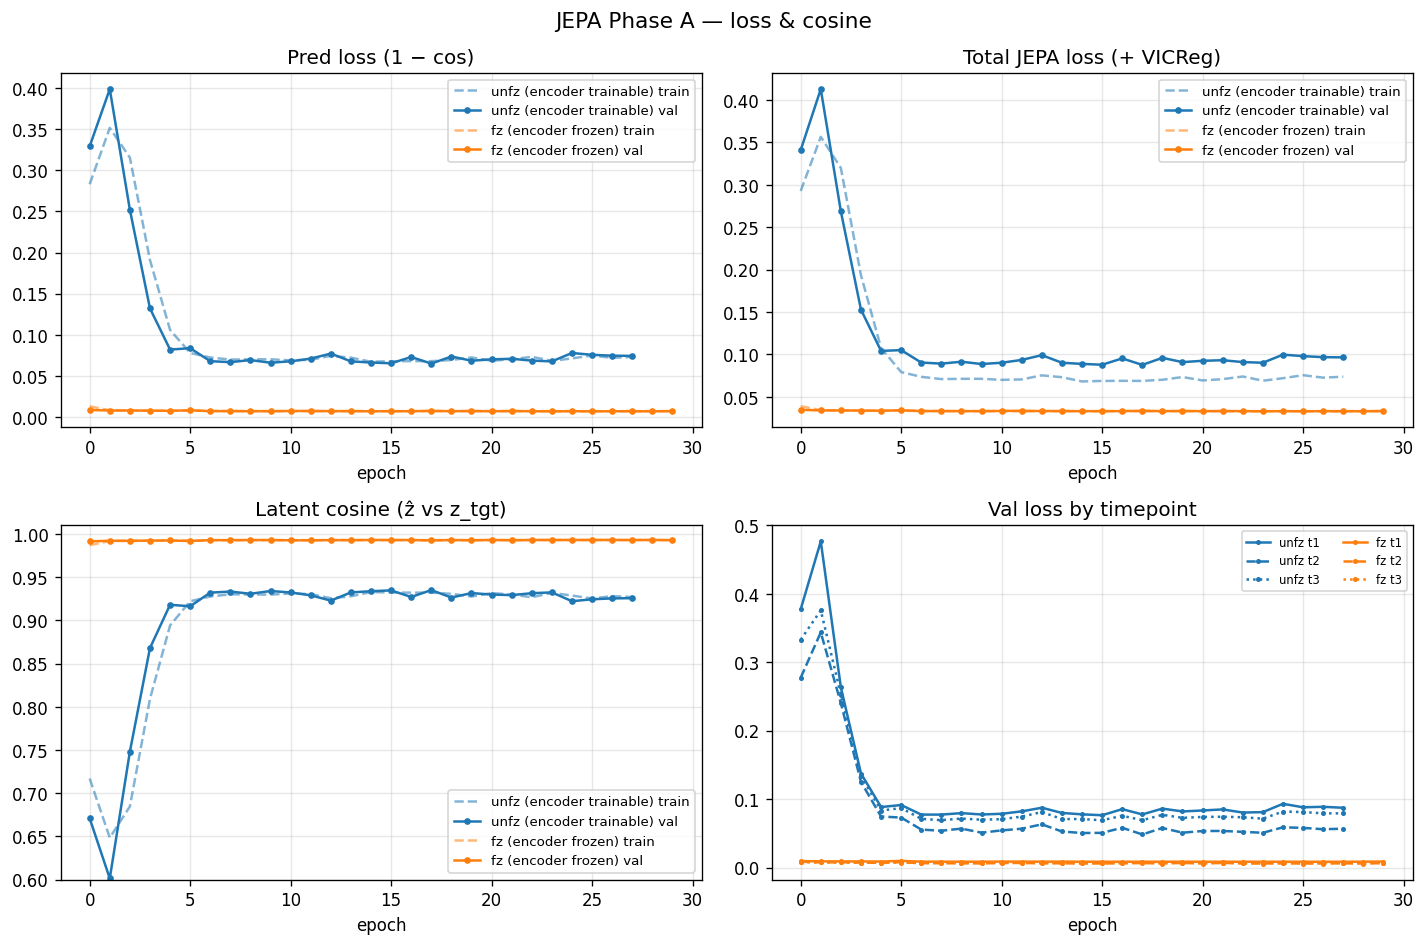

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# pred loss
ax = axes[0, 0]
for name, by in tables.items():
    c = RUNS[name]["color"]
    lab = RUNS[name]["label"]
    if "train/jepa_pred_loss_epoch" in by:
        ax.plot(by.index, by["train/jepa_pred_loss_epoch"], "--", color=c, alpha=0.55, label=f"{lab} train")
    if "val/jepa_pred_loss" in by:
        ax.plot(by.index, by["val/jepa_pred_loss"], "o-", color=c, ms=3, label=f"{lab} val")
ax.set_title("Pred loss (1 − cos)")
ax.set_xlabel("epoch")
ax.legend(fontsize=8)

# total loss (includes VICReg)
ax = axes[0, 1]
for name, by in tables.items():
    c = RUNS[name]["color"]
    lab = RUNS[name]["label"]
    if "train/jepa_loss_epoch" in by:
        ax.plot(by.index, by["train/jepa_loss_epoch"], "--", color=c, alpha=0.55, label=f"{lab} train")
    if "val/jepa_loss" in by:
        ax.plot(by.index, by["val/jepa_loss"], "o-", color=c, ms=3, label=f"{lab} val")
ax.set_title("Total JEPA loss (+ VICReg)")
ax.set_xlabel("epoch")
ax.legend(fontsize=8)

# latent cosine
ax = axes[1, 0]
for name, by in tables.items():
    c = RUNS[name]["color"]
    lab = RUNS[name]["label"]
    if "train/latent_cosine" in by:
        ax.plot(by.index, by["train/latent_cosine"], "--", color=c, alpha=0.55, label=f"{lab} train")
    if "val/latent_cosine" in by:
        ax.plot(by.index, by["val/latent_cosine"], "o-", color=c, ms=3, label=f"{lab} val")
ax.set_title("Latent cosine (ẑ vs z_tgt)")
ax.set_xlabel("epoch")
ax.set_ylim(0.6, 1.01)
ax.legend(fontsize=8)

# per-time val loss
ax = axes[1, 1]
styles = {"val/jepa_loss_t1": "-", "val/jepa_loss_t2": "--", "val/jepa_loss_t3": ":"}
for name, by in tables.items():
    c = RUNS[name]["color"]
    short = "unfz" if "unfz" in name else "fz"
    for col, sty in styles.items():
        if col in by:
            ax.plot(by.index, by[col], sty, color=c, ms=2, marker="o", label=f"{short} {col.split('_')[-1]}")
ax.set_title("Val loss by timepoint")
ax.set_xlabel("epoch")
ax.legend(fontsize=7, ncol=2)

fig.suptitle("JEPA Phase A — loss & cosine", fontsize=13)
fig.tight_layout()
p = OUT_DIR / "nb_loss_cosine.png"
fig.savefig(p, dpi=150, bbox_inches="tight")
print("Wrote", p)
plt.show()

## 4. Collapse & identity baselines

- **`collapse_mean_cosine`**: mean pairwise cosine among target latents (exclude diagonal). Closer to **1.0** ⇒ more collapsed.
- **Identity cos-loss**: `1 − cos(z_src, z_tgt)`. If this is tiny, src≈tgt already → prediction is easy for the wrong reason.
- **Beats identity**: fraction of examples where JEPA cos-loss < identity cos-loss.

Wrote /home/stuke1/perturbgen/Perturbgen/docs/examples/jepa_compare_1120_vs_1128/nb_collapse_baselines.png


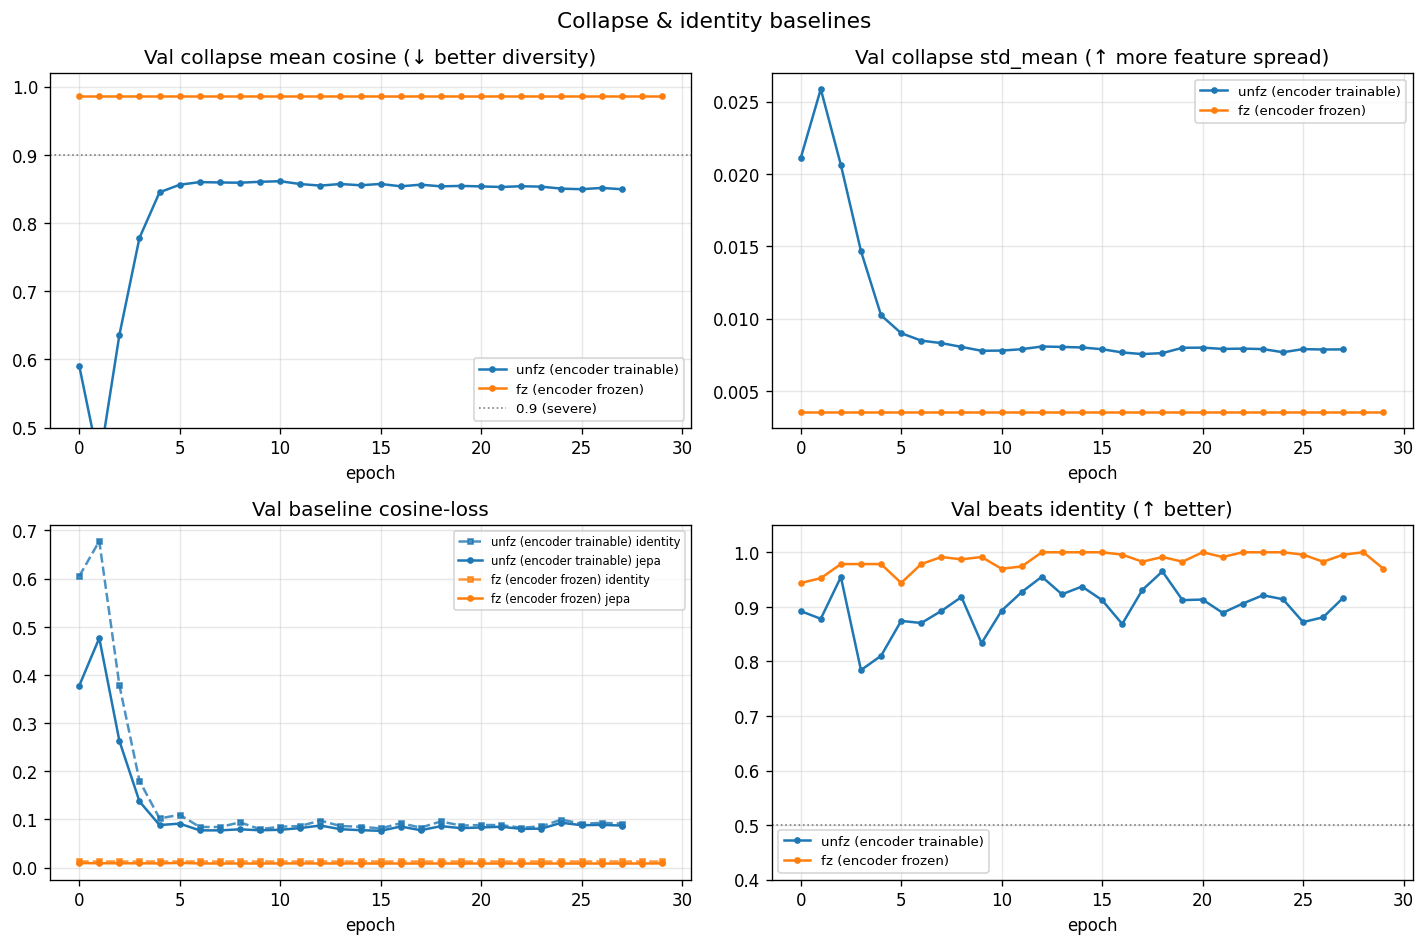

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

ax = axes[0, 0]
for name, by in tables.items():
    c, lab = RUNS[name]["color"], RUNS[name]["label"]
    if "val/collapse_mean_cosine" in by:
        ax.plot(by.index, by["val/collapse_mean_cosine"], "o-", color=c, ms=3, label=lab)
ax.axhline(0.9, color="gray", ls=":", lw=1, label="0.9 (severe)")
ax.set_title("Val collapse mean cosine (↓ better diversity)")
ax.set_xlabel("epoch")
ax.set_ylim(0.5, 1.02)
ax.legend(fontsize=8)

ax = axes[0, 1]
for name, by in tables.items():
    c, lab = RUNS[name]["color"], RUNS[name]["label"]
    if "val/collapse_std_mean" in by:
        ax.plot(by.index, by["val/collapse_std_mean"], "o-", color=c, ms=3, label=lab)
ax.set_title("Val collapse std_mean (↑ more feature spread)")
ax.set_xlabel("epoch")
ax.legend(fontsize=8)

ax = axes[1, 0]
for name, by in tables.items():
    c, lab = RUNS[name]["color"], RUNS[name]["label"]
    if "val/baseline_identity_cosine_loss" in by:
        ax.plot(by.index, by["val/baseline_identity_cosine_loss"], "s--", color=c, ms=3, alpha=0.8, label=f"{lab} identity")
    if "val/baseline_jepa_cosine_loss" in by:
        ax.plot(by.index, by["val/baseline_jepa_cosine_loss"], "o-", color=c, ms=3, label=f"{lab} jepa")
ax.set_title("Val baseline cosine-loss")
ax.set_xlabel("epoch")
ax.legend(fontsize=7)

ax = axes[1, 1]
for name, by in tables.items():
    c, lab = RUNS[name]["color"], RUNS[name]["label"]
    if "val/beats_identity" in by:
        ax.plot(by.index, by["val/beats_identity"], "o-", color=c, ms=3, label=lab)
ax.axhline(0.5, color="gray", ls=":", lw=1)
ax.set_title("Val beats identity (↑ better)")
ax.set_xlabel("epoch")
ax.set_ylim(0.4, 1.05)
ax.legend(fontsize=8)

fig.suptitle("Collapse & identity baselines", fontsize=13)
fig.tight_layout()
p = OUT_DIR / "nb_collapse_baselines.png"
fig.savefig(p, dpi=150, bbox_inches="tight")
print("Wrote", p)
plt.show()

## 5. VICReg terms (anti-collapse regularizer)

Wrote /home/stuke1/perturbgen/Perturbgen/docs/examples/jepa_compare_1120_vs_1128/nb_vicreg.png


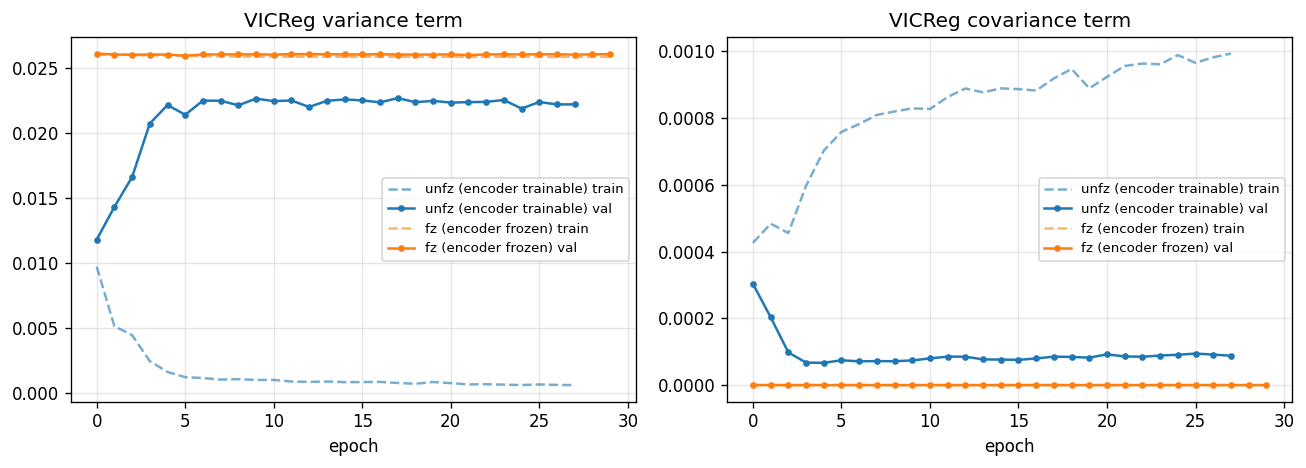

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
for name, by in tables.items():
    c, lab = RUNS[name]["color"], RUNS[name]["label"]
    if "train/vicreg_var" in by:
        ax.plot(by.index, by["train/vicreg_var"], "--", color=c, alpha=0.6, label=f"{lab} train")
    if "val/vicreg_var" in by:
        ax.plot(by.index, by["val/vicreg_var"], "o-", color=c, ms=3, label=f"{lab} val")
ax.set_title("VICReg variance term")
ax.set_xlabel("epoch")
ax.legend(fontsize=8)

ax = axes[1]
for name, by in tables.items():
    c, lab = RUNS[name]["color"], RUNS[name]["label"]
    if "train/vicreg_cov" in by:
        ax.plot(by.index, by["train/vicreg_cov"], "--", color=c, alpha=0.6, label=f"{lab} train")
    if "val/vicreg_cov" in by:
        ax.plot(by.index, by["val/vicreg_cov"], "o-", color=c, ms=3, label=f"{lab} val")
ax.set_title("VICReg covariance term")
ax.set_xlabel("epoch")
ax.legend(fontsize=8)

fig.tight_layout()
p = OUT_DIR / "nb_vicreg.png"
fig.savefig(p, dpi=150, bbox_inches="tight")
print("Wrote", p)
plt.show()

## 6. Per-run detail panels

Wrote /home/stuke1/perturbgen/Perturbgen/docs/examples/jepa_compare_1120_vs_1128/nb_unfz_1120_detail.png


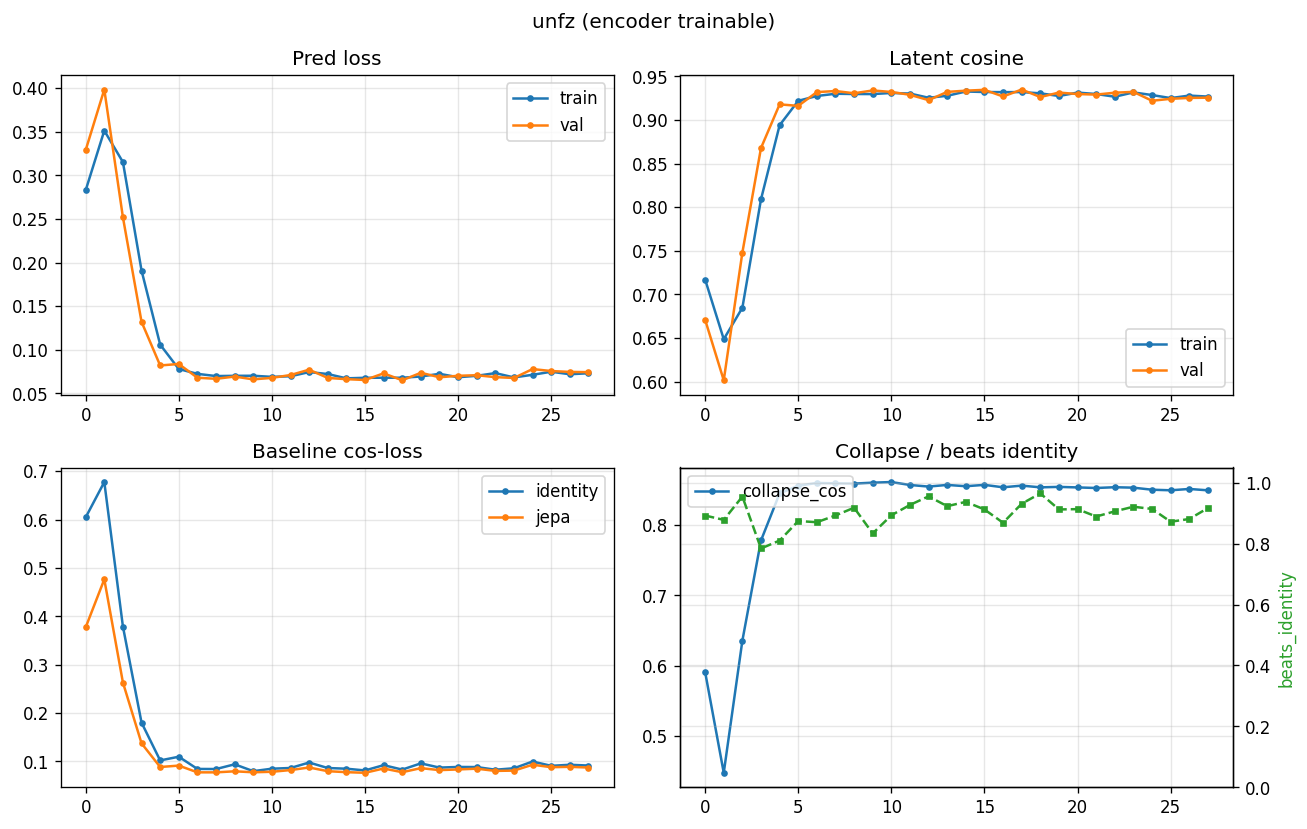

Wrote /home/stuke1/perturbgen/Perturbgen/docs/examples/jepa_compare_1120_vs_1128/nb_fz_1128_detail.png


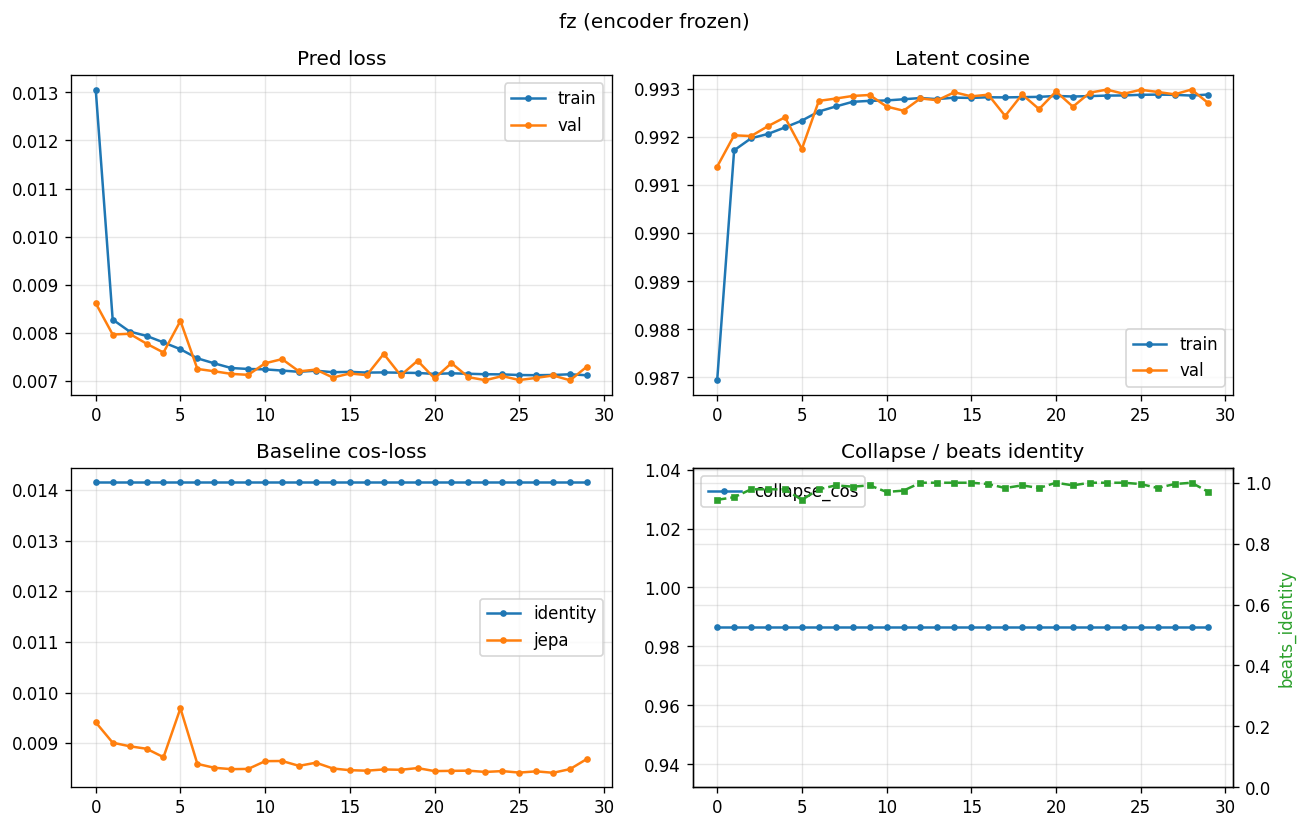

In [10]:
def plot_one_run(name: str, by: pd.DataFrame):
    fig, axes = plt.subplots(2, 2, figsize=(11, 7))
    lab = RUNS[name]["label"]

    ax = axes[0, 0]
    if "train/jepa_pred_loss_epoch" in by:
        ax.plot(by.index, by["train/jepa_pred_loss_epoch"], "o-", label="train", ms=3)
    if "val/jepa_pred_loss" in by:
        ax.plot(by.index, by["val/jepa_pred_loss"], "o-", label="val", ms=3)
    ax.set_title("Pred loss")
    ax.legend()

    ax = axes[0, 1]
    if "train/latent_cosine" in by:
        ax.plot(by.index, by["train/latent_cosine"], "o-", label="train", ms=3)
    if "val/latent_cosine" in by:
        ax.plot(by.index, by["val/latent_cosine"], "o-", label="val", ms=3)
    ax.set_title("Latent cosine")
    ax.legend()

    ax = axes[1, 0]
    if "val/baseline_identity_cosine_loss" in by:
        ax.plot(by.index, by["val/baseline_identity_cosine_loss"], "o-", label="identity", ms=3)
    if "val/baseline_jepa_cosine_loss" in by:
        ax.plot(by.index, by["val/baseline_jepa_cosine_loss"], "o-", label="jepa", ms=3)
    ax.set_title("Baseline cos-loss")
    ax.legend()

    ax = axes[1, 1]
    if "val/collapse_mean_cosine" in by:
        ax.plot(by.index, by["val/collapse_mean_cosine"], "o-", label="collapse_cos", ms=3)
    if "val/beats_identity" in by:
        ax2 = ax.twinx()
        ax2.plot(by.index, by["val/beats_identity"], "s--", color="C2", label="beats_id", ms=3)
        ax2.set_ylabel("beats_identity", color="C2")
        ax2.set_ylim(0, 1.05)
    ax.set_title("Collapse / beats identity")
    ax.legend(loc="upper left")

    fig.suptitle(lab)
    fig.tight_layout()
    p = OUT_DIR / f"nb_{name}_detail.png"
    fig.savefig(p, dpi=150, bbox_inches="tight")
    print("Wrote", p)
    plt.show()


for name in RUNS:
    plot_one_run(name, tables[name])

## 7. Interpretation notes

Fill / edit after you look at the plots:

1. **Did unfz learn?** Large drop in val pred loss from epoch 0 → best, with rising latent cosine.
2. **Is fz “too easy”?** Epoch-0 pred loss already tiny + identity cos-loss tiny + collapse ≈ 0.99 ⇒ frozen features nearly constant across cells/time; predictor looks great but representations are collapsed.
3. **Which to take to Phase B/D?** Prefer the run with non-trivial identity baseline and lower collapse, even if raw pred loss is worse.

Checkpoints:
- unfz: `.../res/jepa/checkpoints/20260804_1120_cellgen_train_jepa_...-epoch=19.ckpt`
- fz: `.../res/jepa/checkpoints/20260805_1128_..._L3_fz_.../epoch=29.ckpt` (or best by val loss)

In [11]:
# Quick verdict helper (auto)
u_best = summary.set_index("run").loc["unfz_1120"]
f_best = summary.set_index("run").loc["fz_1128"]

print("=== Auto notes ===")
print(
    f"unfz learned? ep0→best pred {u_best['ep0_val_pred_loss']:.4f} → {u_best['best_val_pred_loss']:.4f} "
    f"(Δ={u_best['ep0_val_pred_loss'] - u_best['best_val_pred_loss']:.4f})"
)
print(
    f"fz learned?   ep0→best pred {f_best['ep0_val_pred_loss']:.4f} → {f_best['best_val_pred_loss']:.4f} "
    f"(Δ={f_best['ep0_val_pred_loss'] - f_best['best_val_pred_loss']:.4f})"
)
print(
    f"collapse @ best: unfz={u_best['best_collapse_mean_cos']:.3f}  fz={f_best['best_collapse_mean_cos']:.3f}"
)
print(
    f"identity cos-loss @ best: unfz={u_best['best_identity_cos_loss']:.4f}  fz={f_best['best_identity_cos_loss']:.4f}"
)
if f_best["best_collapse_mean_cos"] > 0.95 and f_best["best_identity_cos_loss"] < 0.05:
    print(
        "→ fz looks collapsed / trivial-identity: do NOT prefer fz just because pred loss is lower."
    )
if u_best["ep0_val_pred_loss"] - u_best["best_val_pred_loss"] > 0.1:
    print("→ unfz shows clear learning dynamics; better candidate for Phase B/D if collapse stays tolerable.")

=== Auto notes ===
unfz learned? ep0→best pred 0.3291 → 0.0650 (Δ=0.2641)
fz learned?   ep0→best pred 0.0086 → 0.0070 (Δ=0.0016)
collapse @ best: unfz=0.856  fz=0.986
identity cos-loss @ best: unfz=0.0830  fz=0.0142
→ fz looks collapsed / trivial-identity: do NOT prefer fz just because pred loss is lower.
→ unfz shows clear learning dynamics; better candidate for Phase B/D if collapse stays tolerable.
